# DeepLense Specific Test VII — Eqv-LensPINN Pass 1 + Pass 2 (Single-Seed, No Ensemble)

This notebook keeps the **pass 1 + pass 2 improvements**:

- longer training (`48` epochs)
- slower cosine-style physics ramp
- physics gate capped at `0.8`
- higher-fidelity physics branch (`physics_size = 96`)
- physics-preprocessed auxiliary maps

But it is simplified for Kaggle compute:

- **single seed only**
- **no EMA**
- **no multi-seed or top-k ensemble inference**
- **single best checkpoint + optional D4 TTA**

This avoids the `ModelEMA` key mismatch that can happen with `escnn` state dictionaries while preserving the main model logic.


In [20]:
# # P100 / Pascal compatibility fix for Kaggle
# # Run once, then RESTART the kernel and rerun the notebook from the top.

# import sys
# import subprocess

# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", "-q", "--upgrade",
#     "torch==2.9.1", "torchvision==0.24.1", "torchaudio==2.9.1",
#     "--index-url", "https://download.pytorch.org/whl/cu126",
# ])

# raise SystemExit("Installed cu126 PyTorch wheels. Restart the kernel now, then rerun all cells.")

In [21]:
# ============================================================
# 0) Bootstrap for Kaggle P100 (Pascal sm_60) + escnn install
# Run this cell FIRST. If it exits, restart the kernel and rerun.
# ============================================================
import os
import sys
import subprocess
import importlib.util

NEED_RESTART = False

def _run(cmd):
    print(" ".join(cmd))
    subprocess.check_call(cmd)

import torch

print("Preinstalled torch:", torch.__version__)
print("Preinstalled torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))

# P100 / Pascal fix: CUDA 12.8+ wheels can fail on P100, so keep cu126
if torch.cuda.is_available():
    cc_major, cc_minor = torch.cuda.get_device_capability(0)
    cuda_ver = tuple(int(x) for x in str(torch.version.cuda).split(".")[:2]) if torch.version.cuda else (0, 0)
    if cc_major == 6 and cuda_ver >= (12, 8):
        _run([
            sys.executable, "-m", "pip", "install", "-q", "--upgrade",
            "torch==2.9.1", "torchvision==0.24.1", "torchaudio==2.9.1",
            "--index-url", "https://download.pytorch.org/whl/cu126",
        ])
        NEED_RESTART = True

# escnn install: prefer known-available PyPI release, then fallback
if importlib.util.find_spec("escnn") is None:
    installed = False

    candidates = [
        [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "escnn==1.0.11"],
        [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "escnn"],
        [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "git+https://github.com/QUVA-Lab/escnn"],
    ]

    for cmd in candidates:
        try:
            _run(cmd)
            installed = True
            NEED_RESTART = True
            break
        except subprocess.CalledProcessError as e:
            print("Install attempt failed:", e)

    if not installed:
        raise RuntimeError("Could not install escnn from PyPI or GitHub.")

if NEED_RESTART:
    raise SystemExit("Installed/updated packages. Restart the Kaggle kernel, then rerun from the top.")
else:
    print("Environment looks ready.")

Preinstalled torch: 2.9.1+cu126
Preinstalled torch CUDA: 12.6
CUDA available: True
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)
Environment looks ready.


In [22]:
# ==========================================
# PyTorch smoke test for Kaggle GPU runtime
# ==========================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

print("torch version:", torch.__version__)
print("torch cuda runtime:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("compute capability:", torch.cuda.get_device_capability(0))

# 1) basic tensor ops on device
x = torch.randn(8, 3, 150, 150, device=device)
y = x.mean(dim=(-1, -2), keepdim=True)
z = (x - y) / (x.std(dim=(-1, -2), keepdim=True) + 1e-6)

print("basic tensor ops OK")
print("x shape:", x.shape)
print("z finite:", torch.isfinite(z).all().item())

torch version: 2.9.1+cu126
torch cuda runtime: 12.6
cuda available: True
device: cuda
gpu: Tesla P100-PCIE-16GB
compute capability: (6, 0)
basic tensor ops OK
x shape: torch.Size([8, 3, 150, 150])
z finite: True


In [23]:

# =========================
# 1) Imports
# =========================
import os
import gc
import cv2
import math
import time
import copy
import random
import shutil
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.ops import StochasticDepth

from escnn import gspaces, nn as enn

warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("torch CUDA runtime:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("compute capability:", torch.cuda.get_device_capability(0))

torch: 2.9.1+cu126
torch CUDA runtime: 12.6
cuda available: True
device: Tesla P100-PCIE-16GB
compute capability: (6, 0)


In [24]:

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    # paths
    dataset_root: str = "/kaggle/input/datasets/ashaeyx/dataset-task-vii/dataset"
    work_dir: str = "/kaggle/working/eqv_lenspinn_pass12_single_seed"

    # split handling
    merge_train_val: bool = False
    val_size: float = 0.10
    seed: int = 42

    # data
    img_size: int = 160
    physics_size: int = 96   # pass 2: higher-fidelity physics branch
    class_names: Tuple[str, ...] = ("no", "sphere", "vort")
    batch_size: int = 12
    num_workers: int = 4
    pin_memory: bool = True

    # optimization
    epochs: int = 48         # pass 1: train longer
    warmup_epochs: int = 5
    ramp_epochs: int = 15    # pass 1: slower physics ramp
    physics_gate_max: float = 0.80
    lr: float = 2e-4
    min_lr: float = 5e-6
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    use_amp: bool = True
    label_smoothing: float = 0.03

    # model
    group_order: int = 8
    base_reps: int = 12
    drop_rate: float = 0.20
    phys_hidden: int = 192
    preproc_hidden: int = 128
    source_hidden: int = 64

    # losses
    w_cls: float = 1.0
    w_recon: float = 0.05
    w_alpha_cons: float = 0.02
    w_div: float = 0.01
    w_curl: float = 0.005
    w_tv: float = 1e-4
    w_source_compact: float = 0.01

    # checkpoint / eval
    top_k: int = 3
    early_stopping_patience: int = 12
    use_d4_tta: bool = True

CFG = CFG()
os.makedirs(CFG.work_dir, exist_ok=True)

CLASS_TO_IDX = {c: i for i, c in enumerate(CFG.class_names)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(CFG)
print("DEVICE:", DEVICE)


CFG(dataset_root='/kaggle/input/datasets/ashaeyx/dataset-task-vii/dataset', work_dir='/kaggle/working/eqv_lenspinn_pass12_single_seed', merge_train_val=False, val_size=0.1, seed=42, img_size=160, physics_size=96, class_names=('no', 'sphere', 'vort'), batch_size=12, num_workers=4, pin_memory=True, epochs=48, warmup_epochs=5, ramp_epochs=15, physics_gate_max=0.8, lr=0.0002, min_lr=5e-06, weight_decay=0.0001, grad_clip=1.0, use_amp=True, label_smoothing=0.03, group_order=8, base_reps=12, drop_rate=0.2, phys_hidden=192, preproc_hidden=128, source_hidden=64, w_cls=1.0, w_recon=0.05, w_alpha_cons=0.02, w_div=0.01, w_curl=0.005, w_tv=0.0001, w_source_compact=0.01, top_k=3, early_stopping_patience=12, use_d4_tta=True)
DEVICE: cuda


In [25]:

# =========================
# 3) Reproducibility
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # safer than full deterministic mode for escnn / CUDA speed
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(CFG.seed)

In [26]:
# =========================
# 4) Dataset indexing
# =========================
def index_split(root: Path, split_name: str, class_names: Tuple[str, ...]):
    rows = []
    split_root = root / split_name
    if not split_root.exists():
        raise FileNotFoundError(f"Missing split directory: {split_root}")

    for cname in class_names:
        class_dir = split_root / cname
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class directory: {class_dir}")

        files = sorted(class_dir.glob("*.npy"))
        if len(files) == 0:
            raise RuntimeError(f"No .npy files found under {class_dir}")

        for p in files:
            rows.append({"path": str(p), "label_name": cname, "label": CLASS_TO_IDX[cname], "split": split_name})

    return pd.DataFrame(rows)

def make_splits(cfg: CFG):
    root = Path(cfg.dataset_root)
    train_df = index_split(root, "train", cfg.class_names)
    val_df = index_split(root, "val", cfg.class_names)

    if cfg.merge_train_val:
        full_df = pd.concat([train_df, val_df], ignore_index=True)
        train_parts, val_parts = [], []
        for c in cfg.class_names:
            cdf = full_df[full_df.label_name == c].sample(frac=1.0, random_state=cfg.seed).reset_index(drop=True)
            n_val = max(1, int(round(len(cdf) * cfg.val_size)))
            val_parts.append(cdf.iloc[:n_val].copy())
            train_parts.append(cdf.iloc[n_val:].copy())
        train_df = pd.concat(train_parts, ignore_index=True).sample(frac=1.0, random_state=cfg.seed).reset_index(drop=True)
        val_df = pd.concat(val_parts, ignore_index=True).sample(frac=1.0, random_state=cfg.seed).reset_index(drop=True)
        train_df["split"] = "train_resplit"
        val_df["split"] = "val_resplit"

    os.makedirs(cfg.work_dir, exist_ok=True)
    train_df.to_csv(os.path.join(cfg.work_dir, "train_split.csv"), index=False)
    val_df.to_csv(os.path.join(cfg.work_dir, "val_split.csv"), index=False)
    return train_df, val_df

train_df, val_df = make_splits(CFG)
display(train_df.head())
print(train_df.label_name.value_counts())
print(val_df.label_name.value_counts())
print("train size:", len(train_df), "| val size:", len(val_df))

,path,label_name,label,split
0,/kaggle/input/datasets/ashaeyx/dataset-task-vi...,no,0,train
1,/kaggle/input/datasets/ashaeyx/dataset-task-vi...,no,0,train
2,/kaggle/input/datasets/ashaeyx/dataset-task-vi...,no,0,train
3,/kaggle/input/datasets/ashaeyx/dataset-task-vi...,no,0,train
4,/kaggle/input/datasets/ashaeyx/dataset-task-vi...,no,0,train


label_name
no        10000
sphere    10000
vort      10000
Name: count, dtype: int64
label_name
no        2500
sphere    2500
vort      2500
Name: count, dtype: int64
train size: 30000 | val size: 7500


In [27]:
# =========================
# 5) Augmentations / dataset / loaders
# =========================
class LensDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_size: int, train: bool):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.df)

    def _load_npy(self, path: str):
        arr = np.load(path)
        arr = np.asarray(arr, dtype=np.float32)

        if arr.ndim == 3:
            if arr.shape[0] == 1:
                arr = arr[0]
            elif arr.shape[-1] == 1:
                arr = arr[..., 0]
            else:
                arr = arr[..., 0]

        if arr.ndim != 2:
            raise ValueError(f"Expected 2D lens image, got shape {arr.shape} for {path}")

        amin, amax = float(arr.min()), float(arr.max())
        if amin < -1e-6 or amax > 1.0 + 1e-6:
            arr = (arr - amin) / (amax - amin + 1e-8)

        arr = np.clip(arr, 0.0, 1.0)
        return arr

    def _d4_aug(self, x: np.ndarray):
        k = np.random.randint(0, 4)
        x = np.rot90(x, k).copy()
        if np.random.rand() < 0.5:
            x = np.fliplr(x).copy()
        if np.random.rand() < 0.5:
            x = np.flipud(x).copy()
        if np.random.rand() < 0.25:
            x = x + np.random.normal(0.0, 0.01, size=x.shape).astype(np.float32)
            x = np.clip(x, 0.0, 1.0)
        return x

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = self._load_npy(row.path)
        if self.train:
            x = self._d4_aug(x)

        x = torch.from_numpy(x).float()[None, ...]
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(
                x.unsqueeze(0),
                size=(self.img_size, self.img_size),
                mode="bilinear",
                align_corners=False,
            )[0]

        return {
            "image": x,
            "label": torch.tensor(int(row.label), dtype=torch.long),
            "path": row.path,
        }

def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def build_loaders(cfg: CFG, train_df: pd.DataFrame, val_df: pd.DataFrame):
    train_ds = LensDataset(train_df, cfg.img_size, train=True)
    val_ds = LensDataset(val_df, cfg.img_size, train=False)

    g = torch.Generator()
    g.manual_seed(cfg.seed)

    loader_kwargs = dict(
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=g,
    )
    if cfg.num_workers > 0:
        loader_kwargs["persistent_workers"] = True

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        **loader_kwargs,
    )
    return train_loader, val_loader

train_loader, val_loader = build_loaders(CFG, train_df, val_df)
batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"].shape)

torch.Size([12, 1, 160, 160]) torch.Size([12])


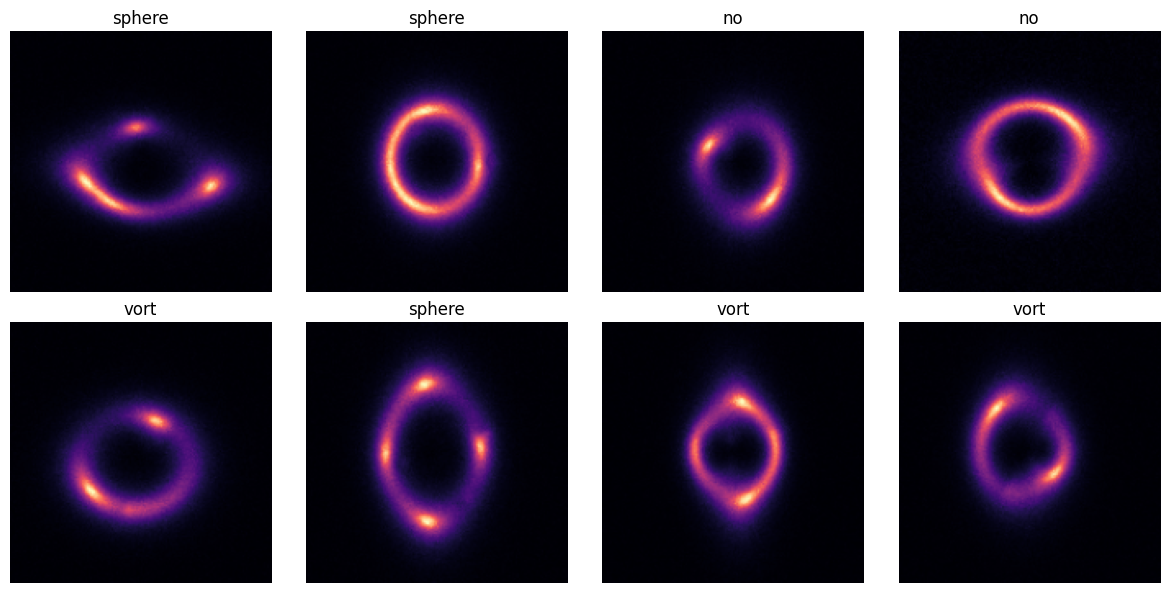

In [28]:

# =========================
# 6) Visual sanity check
# =========================
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i in range(8):
    img = batch["image"][i, 0].numpy()
    lbl = batch["label"][i].item()
    axes[i].imshow(img, cmap="magma")
    axes[i].set_title(IDX_TO_CLASS[lbl])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [29]:
# =========================
# 7) Math + preprocessing helpers
# =========================
def make_coord_grid(batch_size: int, h: int, w: int, device, dtype):
    ys = torch.linspace(-1.0, 1.0, h, device=device, dtype=dtype)
    xs = torch.linspace(-1.0, 1.0, w, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    grid = torch.stack([xx, yy], dim=-1)
    return grid.unsqueeze(0).repeat(batch_size, 1, 1, 1)

def _fixed_kernel(weight, channels, device, dtype):
    k = torch.tensor(weight, device=device, dtype=dtype).view(1, 1, 3, 3)
    return k.repeat(channels, 1, 1, 1)

def gradients_xy(x: torch.Tensor):
    c = x.shape[1]
    kx = _fixed_kernel([[0, 0, 0], [-0.5, 0.0, 0.5], [0, 0, 0]], c, x.device, x.dtype)
    ky = _fixed_kernel([[0, -0.5, 0], [0, 0.0, 0], [0, 0.5, 0]], c, x.device, x.dtype)
    xpad = F.pad(x, (1, 1, 1, 1), mode="replicate")
    gx = F.conv2d(xpad, kx, groups=c)
    gy = F.conv2d(xpad, ky, groups=c)
    return gx, gy

def laplacian(x: torch.Tensor):
    c = x.shape[1]
    kl = _fixed_kernel([[0, 1, 0], [1, -4, 1], [0, 1, 0]], c, x.device, x.dtype)
    xpad = F.pad(x, (1, 1, 1, 1), mode="replicate")
    return F.conv2d(xpad, kl, groups=c)

def divergence(alpha: torch.Tensor):
    ax, ay = alpha[:, 0:1], alpha[:, 1:2]
    ax_x, _ = gradients_xy(ax)
    _, ay_y = gradients_xy(ay)
    return ax_x + ay_y

def curl2d(alpha: torch.Tensor):
    ax, ay = alpha[:, 0:1], alpha[:, 1:2]
    _, ax_y = gradients_xy(ax)
    ay_x, _ = gradients_xy(ay)
    return ay_x - ax_y

def total_variation(x: torch.Tensor):
    return (x[..., :, 1:] - x[..., :, :-1]).abs().mean() + (x[..., 1:, :] - x[..., :-1, :]).abs().mean()

def safe_std(x: torch.Tensor, dims):
    mean = x.mean(dim=dims, keepdim=False)
    mean_sq = (x ** 2).mean(dim=dims, keepdim=False)
    var = (mean_sq - mean ** 2).clamp_min(1e-12)
    return torch.sqrt(var)

def blur3x3(x: torch.Tensor):
    return F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)

def sobel_magnitude(x: torch.Tensor):
    gx, gy = gradients_xy(x)
    return torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)

def local_contrast_map(x: torch.Tensor):
    mu = blur3x3(x)
    var = blur3x3((x - mu) ** 2)
    return (x - mu) / torch.sqrt(var + 1e-6)

def radial_residual_map(x: torch.Tensor, num_bins: int = 16):
    # x: [B, 1, H, W]
    b, c, h, w = x.shape
    device, dtype = x.device, x.dtype
    rr = make_coord_grid(b, h, w, device, dtype)
    rr = torch.sqrt(rr[..., 0] ** 2 + rr[..., 1] ** 2).clamp_min(0.0)
    rr = rr / rr.amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
    bin_idx = torch.clamp((rr * (num_bins - 1)).long(), 0, num_bins - 1)

    out = torch.zeros_like(x)
    for bi in range(b):
        vals = x[bi, 0]
        idx = bin_idx[bi]
        for k in range(num_bins):
            mask = idx == k
            if mask.any():
                m = vals[mask].mean()
                out[bi, 0][mask] = vals[mask] - m
    return out.abs()

def build_preprocessed_maps(x: torch.Tensor):
    # x: [B,1,H,W], already resized to physics feature resolution
    blur = blur3x3(x)
    highpass = x - blur
    lap = laplacian(x)
    sob = sobel_magnitude(x)
    contrast = local_contrast_map(x)
    radial = radial_residual_map(x)
    return torch.cat([x, highpass, lap, sob, contrast, radial], dim=1)

In [30]:
# =========================
# 8) Model blocks
# =========================
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, drop=0.0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU(inplace=True)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class SmallPhysicsEncoder(nn.Module):
    def __init__(self, in_ch, hidden=192, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, 64, 3, 1, 1, drop=0.0),
            ConvBNAct(64, 96, 3, 2, 1, drop=drop),
            ConvBNAct(96, 128, 3, 2, 1, drop=drop),
            ConvBNAct(128, hidden, 3, 2, 1, drop=drop),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.net(x)
        return self.pool(x).flatten(1)

class SmallSourceDecoder(nn.Module):
    def __init__(self, in_ch=104, hidden=64, drop=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, hidden, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.SiLU(inplace=True),
            nn.Dropout2d(drop),

            nn.Conv2d(hidden, hidden, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.SiLU(inplace=True),
            nn.Dropout2d(drop),

            nn.Conv2d(hidden, hidden // 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(hidden // 2),
            nn.SiLU(inplace=True),

            nn.Conv2d(hidden // 2, 1, kernel_size=1, stride=1, padding=0),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

In [31]:
# =========================
# 9) C8 steerable trunk + LensPINN hybrid + preprocessing branch
# =========================
class C8SteerableBackbone(nn.Module):
    def __init__(self, group_order=8, base_reps=12, drop_rate=0.2):
        super().__init__()
        self.r2 = gspaces.rot2dOnR2(N=group_order)

        in_type = enn.FieldType(self.r2, [self.r2.trivial_repr])
        t1 = enn.FieldType(self.r2, base_reps * [self.r2.regular_repr])
        t2 = enn.FieldType(self.r2, (base_reps + 6) * [self.r2.regular_repr])
        t3 = enn.FieldType(self.r2, (base_reps + 12) * [self.r2.regular_repr])
        t4 = enn.FieldType(self.r2, (base_reps + 20) * [self.r2.regular_repr])

        self.block1 = enn.SequentialModule(
            enn.R2Conv(in_type, t1, kernel_size=7, padding=3, bias=False),
            enn.InnerBatchNorm(t1),
            enn.ReLU(t1, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(t1, sigma=0.66, stride=2)

        self.block2 = enn.SequentialModule(
            enn.R2Conv(t1, t2, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(t2),
            enn.ReLU(t2, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(t2, sigma=0.66, stride=2)

        self.block3 = enn.SequentialModule(
            enn.R2Conv(t2, t3, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(t3),
            enn.ReLU(t3, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(t3, sigma=0.66, stride=2)

        self.block4 = enn.SequentialModule(
            enn.R2Conv(t3, t4, kernel_size=3, padding=1, bias=False),
            enn.InnerBatchNorm(t4),
            enn.ReLU(t4, inplace=True),
        )

        self.gpool = enn.GroupPooling(t4)
        self.drop = nn.Dropout(drop_rate)
        self.out_dim = len(self.gpool.out_type.representations)

    def forward(self, x):
        x = enn.GeometricTensor(x, enn.FieldType(self.r2, [self.r2.trivial_repr]))
        x = self.block1(x)
        x = self.pool1(x)
        x = self.block2(x)
        x = self.pool2(x)
        x = self.block3(x)
        x = self.pool3(x)
        x = self.block4(x)
        x = self.gpool(x)
        x = x.tensor.mean(dim=(-1, -2))
        return self.drop(x)

class EqvLensPINN(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg

        self.visual = C8SteerableBackbone(
            group_order=cfg.group_order,
            base_reps=cfg.base_reps,
            drop_rate=cfg.drop_rate,
        )

        self.physics_stem = nn.Sequential(
            ConvBNAct(1, 32, 3, 1, 1),
            ConvBNAct(32, 48, 3, 2, 1),
            ConvBNAct(48, 64, 3, 1, 1),
            ConvBNAct(64, 80, 3, 2, 1),
            ConvBNAct(80, 96, 3, 1, 1),
        )
        self.physics_pool = nn.AdaptiveAvgPool2d(1)
        self.theta_head = nn.Linear(96, 3)

        self.map_head = nn.Sequential(
            ConvBNAct(96, 96, 3, 1, 1),
            nn.Conv2d(96, 3, 1),
        )

        self.source_decoder = SmallSourceDecoder(
            in_ch=104,
            hidden=cfg.source_hidden,
            drop=cfg.drop_rate,
        )

        self.physics_encoder = SmallPhysicsEncoder(
            in_ch=6,
            hidden=cfg.phys_hidden,
            drop=cfg.drop_rate,
        )
        self.preproc_encoder = SmallPhysicsEncoder(
            in_ch=6,
            hidden=cfg.preproc_hidden,
            drop=cfg.drop_rate,
        )

        self.scalar_mlp = nn.Sequential(
            nn.Linear(8, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(64, 64),
            nn.SiLU(inplace=True),
        )

        fusion_dim = self.visual.out_dim + cfg.phys_hidden + cfg.preproc_hidden + 64
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(256, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(128, len(cfg.class_names)),
        )

        self.physics_gate = 0.0

    def set_physics_gate(self, gate: float):
        self.physics_gate = float(gate)

    def forward(self, x):
        b = x.shape[0]
        x = x.float()

        # visual equivariant branch
        x_vis = (x - x.mean(dim=(-1, -2), keepdim=True)) / (x.std(dim=(-1, -2), keepdim=True) + 1e-6)
        visual_feat = self.visual(x_vis)

        # physics branch
        x_ds = F.interpolate(
            x,
            size=(self.cfg.physics_size, self.cfg.physics_size),
            mode="bilinear",
            align_corners=False,
        )

        feat = self.physics_stem(x_ds)
        hp, wp = feat.shape[-2:]
        x_phy = F.interpolate(x_ds, size=(hp, wp), mode="bilinear", align_corners=False)

        pooled = self.physics_pool(feat).flatten(1)
        theta_raw = self.theta_head(pooled)
        theta_e = 0.08 + 0.42 * torch.sigmoid(theta_raw[:, 0:1]).view(b, 1, 1, 1)
        gamma1 = 0.12 * torch.tanh(theta_raw[:, 1:2]).view(b, 1, 1, 1)
        gamma2 = 0.12 * torch.tanh(theta_raw[:, 2:3]).view(b, 1, 1, 1)

        map_logits = self.map_head(feat)
        psi_res = 0.10 * torch.tanh(map_logits[:, 0:1])
        alpha_pred = 0.35 * torch.tanh(map_logits[:, 1:3])

        grid = make_coord_grid(b, hp, wp, x.device, x.dtype)
        xx = grid[..., 0].unsqueeze(1)
        yy = grid[..., 1].unsqueeze(1)
        rr = torch.sqrt(xx ** 2 + yy ** 2 + 1e-6)

        psi_sis = theta_e * rr
        psi_shear = 0.5 * gamma1 * (xx ** 2 - yy ** 2) + gamma2 * xx * yy
        psi = psi_sis + psi_shear + psi_res

        psi_x, psi_y = gradients_xy(psi)
        alpha_grad = torch.cat([psi_x, psi_y], dim=1)
        alpha = 0.5 * (alpha_pred + alpha_grad)

        beta_x = (xx - alpha[:, 0:1]).clamp(-1.0, 1.0)
        beta_y = (yy - alpha[:, 1:2]).clamp(-1.0, 1.0)
        beta_grid = torch.stack([beta_x[:, 0], beta_y[:, 0]], dim=-1)

        psi_xx, psi_xy = gradients_xy(psi_x)
        psi_yx, psi_yy = gradients_xy(psi_y)

        kappa = 0.5 * (psi_xx + psi_yy)
        gamma1_map = 0.5 * (psi_xx - psi_yy)
        gamma2_map = 0.5 * (psi_xy + psi_yx)
        gamma_mag = torch.sqrt(gamma1_map ** 2 + gamma2_map ** 2 + 1e-8)

        div_alpha = divergence(alpha_pred)
        curl_alpha = curl2d(alpha_pred)

        source_in = torch.cat([feat, x_phy, xx, yy, rr, psi, alpha, kappa], dim=1)
        if source_in.shape[1] != 104:
            raise RuntimeError(f"source_in channels expected 104, got {source_in.shape[1]}")

        source = self.source_decoder(source_in)
        relensed = F.grid_sample(
            source,
            beta_grid,
            mode="bilinear",
            padding_mode="zeros",
            align_corners=True,
        )

        residual = torch.abs(x_phy - relensed)
        critical = torch.sigmoid(6.0 * (gamma_mag + kappa.abs() - 0.5))
        physics_stack = torch.cat([source, relensed, residual, kappa, gamma_mag, critical], dim=1)
        physics_feat = self.physics_encoder(physics_stack)

        # pass 2: physics-preprocessed branch
        preproc_stack = build_preprocessed_maps(x_phy)
        preproc_feat = self.preproc_encoder(preproc_stack)

        scalar_stats = torch.cat(
            [
                theta_e.view(b, 1),
                gamma1.view(b, 1),
                gamma2.view(b, 1),
                residual.mean(dim=(1, 2, 3)).unsqueeze(1),
                residual.amax(dim=(1, 2, 3)).unsqueeze(1),
                kappa.mean(dim=(1, 2, 3)).unsqueeze(1),
                safe_std(kappa, dims=(1, 2, 3)).unsqueeze(1),
                gamma_mag.mean(dim=(1, 2, 3)).unsqueeze(1),
            ],
            dim=1,
        )
        scalar_feat = self.scalar_mlp(scalar_stats)

        gate = self.physics_gate
        fused = torch.cat(
            [visual_feat, gate * physics_feat, gate * preproc_feat, gate * scalar_feat],
            dim=1,
        )
        logits = self.classifier(fused)

        aux = {
            "x_ds": x_ds,
            "x_phy": x_phy,
            "feat": feat,
            "psi": psi,
            "psi_res": psi_res,
            "alpha": alpha,
            "alpha_pred": alpha_pred,
            "alpha_grad": alpha_grad,
            "div_alpha": div_alpha,
            "curl_alpha": curl_alpha,
            "source": source,
            "relensed": relensed,
            "residual": residual,
            "kappa": kappa,
            "gamma_mag": gamma_mag,
            "critical": critical,
            "theta_e": theta_e,
            "preproc_stack": preproc_stack,
            "physics_gate": gate,
        }
        return logits, aux

In [32]:
# =========================
# Physics / loss helper utilities
# =========================
import torch
import torch.nn.functional as F

def safe_std(x, dims=None, keepdim=False, eps=1e-6):
    if dims is None:
        dims = tuple(range(x.ndim))
    mean = x.mean(dim=dims, keepdim=True)
    var = ((x - mean) ** 2).mean(dim=dims, keepdim=True)
    std = torch.sqrt(var + eps)
    if not keepdim:
        for d in sorted(dims, reverse=True):
            std = std.squeeze(d)
    return std

def gradients_xy(x):
    """
    x: [B, C, H, W]
    returns dx, dy with same shape as x
    """
    dx = torch.zeros_like(x)
    dy = torch.zeros_like(x)

    dx[:, :, :, 1:-1] = 0.5 * (x[:, :, :, 2:] - x[:, :, :, :-2])
    dx[:, :, :, 0] = x[:, :, :, 1] - x[:, :, :, 0]
    dx[:, :, :, -1] = x[:, :, :, -1] - x[:, :, :, -2]

    dy[:, :, 1:-1, :] = 0.5 * (x[:, :, 2:, :] - x[:, :, :-2, :])
    dy[:, :, 0, :] = x[:, :, 1, :] - x[:, :, 0, :]
    dy[:, :, -1, :] = x[:, :, -1, :] - x[:, :, -2, :]

    return dx, dy

def divergence(v):
    """
    v: [B, 2, H, W]
    returns div: [B, 1, H, W]
    """
    vx = v[:, 0:1]
    vy = v[:, 1:2]
    dvx_dx, _ = gradients_xy(vx)
    _, dvy_dy = gradients_xy(vy)
    return dvx_dx + dvy_dy

def curl2d(v):
    """
    v: [B, 2, H, W]
    returns scalar curl: [B, 1, H, W]
    """
    vx = v[:, 0:1]
    vy = v[:, 1:2]
    _, dvx_dy = gradients_xy(vx)
    dvy_dx, _ = gradients_xy(vy)
    return dvy_dx - dvx_dy

def laplacian(x):
    """
    x: [B, C, H, W]
    returns laplacian with same shape
    """
    dx, dy = gradients_xy(x)
    dxx, _ = gradients_xy(dx)
    _, dyy = gradients_xy(dy)
    return dxx + dyy

def total_variation(x):
    """
    isotropic-ish TV surrogate
    x: [B, C, H, W]
    """
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    return dx.abs().mean() + dy.abs().mean()

def source_compactness_loss(source):
    """
    Encourage compact source-plane brightness near the center.
    source: [B, 1, H, W], assumed nonnegative / sigmoid output
    """
    b, c, h, w = source.shape
    device = source.device
    dtype = source.dtype

    yy, xx = torch.meshgrid(
        torch.linspace(-1.0, 1.0, h, device=device, dtype=dtype),
        torch.linspace(-1.0, 1.0, w, device=device, dtype=dtype),
        indexing="ij",
    )
    r2 = (xx ** 2 + yy ** 2).view(1, 1, h, w)

    # brightness-weighted radial second moment
    mass = source.sum(dim=(2, 3), keepdim=True).clamp_min(1e-6)
    compact = (source * r2).sum(dim=(2, 3), keepdim=True) / mass
    return compact.mean()

In [33]:

# =========================
# 10) Loss / schedules / metrics / checkpoints
# =========================
class HybridPINNLoss(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
        self.gate = 0.0

        self.w_cls = getattr(cfg, "w_cls", 1.0)
        self.w_recon = getattr(cfg, "w_recon", 0.05)
        self.w_alpha_cons = getattr(cfg, "w_alpha_cons", 0.02)
        self.w_div = getattr(cfg, "w_div", 0.01)
        self.w_curl = getattr(cfg, "w_curl", 0.005)
        self.w_tv = getattr(cfg, "w_tv", 1e-4)
        self.w_source_compact = getattr(cfg, "w_source_compact", 0.01)

    def set_gate(self, gate: float):
        self.gate = float(gate)

    def forward(self, logits, targets, aux):
        loss_cls = self.ce(logits, targets)
        loss_recon = F.smooth_l1_loss(aux["relensed"], aux["x_phy"])
        loss_alpha_cons = F.smooth_l1_loss(aux["alpha_pred"], aux["alpha_grad"].detach())
        loss_div = F.smooth_l1_loss(aux["div_alpha"], laplacian(aux["psi"]).detach())
        loss_curl = F.smooth_l1_loss(aux["curl_alpha"], torch.zeros_like(aux["curl_alpha"]))
        loss_tv = total_variation(aux["psi_res"])
        loss_source_compact = source_compactness_loss(aux["source"])

        gate = self.gate
        total_loss = (
            self.w_cls * loss_cls
            + gate * self.w_recon * loss_recon
            + gate * self.w_alpha_cons * loss_alpha_cons
            + gate * self.w_div * loss_div
            + gate * self.w_curl * loss_curl
            + gate * self.w_tv * loss_tv
            + gate * self.w_source_compact * loss_source_compact
        )
        logs = {
            "loss_cls": float(loss_cls.detach().cpu()),
            "loss_recon": float(loss_recon.detach().cpu()),
            "loss_alpha_cons": float(loss_alpha_cons.detach().cpu()),
            "loss_div": float(loss_div.detach().cpu()),
            "loss_curl": float(loss_curl.detach().cpu()),
            "loss_tv": float(loss_tv.detach().cpu()),
            "loss_source_compact": float(loss_source_compact.detach().cpu()),
            "physics_gate": float(gate),
        }
        return total_loss, logs

def physics_gate_for_epoch(epoch: int, cfg: CFG):
    if epoch <= cfg.warmup_epochs:
        return 0.0
    t = (epoch - cfg.warmup_epochs) / max(1, cfg.ramp_epochs)
    t = float(np.clip(t, 0.0, 1.0))
    t = 0.5 - 0.5 * math.cos(math.pi * t)  # smoother slower ramp
    return float(cfg.physics_gate_max * t)

def multiclass_metrics(y_true, probs):
    y_true = np.asarray(y_true, dtype=np.int64)
    probs = np.asarray(probs, dtype=np.float64)
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, 1e-12, 1.0)
    probs = probs / probs.sum(axis=1, keepdims=True).clip(min=1e-12)

    y_pred = probs.argmax(axis=1)
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    per_class_auc = {}
    n_classes = probs.shape[1]
    for c in range(n_classes):
        y_bin = (y_true == c).astype(np.int32)
        if y_bin.min() == y_bin.max():
            per_class_auc[IDX_TO_CLASS[c]] = np.nan
        else:
            per_class_auc[IDX_TO_CLASS[c]] = float(roc_auc_score(y_bin, probs[:, c]))

    if len(np.unique(y_true)) == n_classes:
        macro_auc_ovr = float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro"))
        weighted_auc_ovr = float(roc_auc_score(y_true, probs, multi_class="ovr", average="weighted"))
    else:
        vals = [v for v in per_class_auc.values() if not np.isnan(v)]
        macro_auc_ovr = float(np.mean(vals)) if len(vals) > 0 else np.nan
        weighted_auc_ovr = macro_auc_ovr

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "macro_auc_ovr": float(macro_auc_ovr),
        "weighted_auc_ovr": float(weighted_auc_ovr),
        "per_class_auc": per_class_auc,
        "y_pred": y_pred,
    }

def _sanitize_for_save(x):
    if isinstance(x, dict):
        return {str(k): _sanitize_for_save(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_sanitize_for_save(v) for v in x]
    if isinstance(x, np.generic):
        return x.item()
    if isinstance(x, np.ndarray):
        return x.tolist()
    return x

class TopKCheckpointManager:
    def __init__(self, save_dir: str, k: int = 3):
        self.save_dir = save_dir
        self.k = k
        self.records = []

    def maybe_save(self, model, epoch: int, metrics: dict, cfg: CFG):
        score = float(metrics["macro_auc_ovr"])
        save_path = os.path.join(self.save_dir, f"epoch{epoch:03d}_auc{score:.6f}.pth")
        payload = {
            "epoch": int(epoch),
            "model_state": model.state_dict(),
            "metrics": _sanitize_for_save({k: v for k, v in metrics.items() if k != "y_pred"}),
            "config": _sanitize_for_save(asdict(cfg)),
        }
        torch.save(payload, save_path)
        self.records.append({"score": score, "path": save_path, "epoch": int(epoch)})
        self.records = sorted(self.records, key=lambda x: x["score"], reverse=True)[: self.k]

        keep = {r["path"] for r in self.records}
        for p in Path(self.save_dir).glob("epoch*_auc*.pth"):
            if str(p) not in keep:
                p.unlink(missing_ok=True)
        return self.records

def load_checkpoint_state(ckpt_path, device):
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    if isinstance(state, dict) and "model_state" in state:
        return state["model_state"], state
    return state, state


In [34]:

# =========================
# 11) Build model (single-seed)
# =========================
model = EqvLensPINN(CFG).to(DEVICE)
criterion = HybridPINNLoss(CFG)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs, eta_min=CFG.min_lr)
scaler = torch.amp.GradScaler("cuda", enabled=(CFG.use_amp and torch.cuda.is_available()))
ckpt_mgr = TopKCheckpointManager(CFG.work_dir, CFG.top_k)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 1,305,038
Trainable params: 1,305,038


In [35]:
x = batch["image"][:2].to(DEVICE)
model.set_physics_gate(1.0)
criterion.set_gate(1.0)

with torch.no_grad():
    logits, aux = model(x)

print("relensed:", aux["relensed"].shape)
print("x_phy   :", aux["x_phy"].shape)
print("x_ds    :", aux["x_ds"].shape)

relensed: torch.Size([2, 1, 24, 24])
x_phy   : torch.Size([2, 1, 24, 24])
x_ds    : torch.Size([2, 1, 96, 96])


In [36]:
# =========================
# Shape smoke test
# =========================
x = batch["image"][:2].to(DEVICE)
model.set_physics_gate(0.0)

with torch.no_grad():
    logits, aux = model(x)

print("logits:", logits.shape)
for k, v in aux.items():
    if torch.is_tensor(v):
        print(f"{k:12s} -> {tuple(v.shape)}")

print("source_in / decoder path OK")

logits: torch.Size([2, 3])
x_ds         -> (2, 1, 96, 96)
x_phy        -> (2, 1, 24, 24)
feat         -> (2, 96, 24, 24)
psi          -> (2, 1, 24, 24)
psi_res      -> (2, 1, 24, 24)
alpha        -> (2, 2, 24, 24)
alpha_pred   -> (2, 2, 24, 24)
alpha_grad   -> (2, 2, 24, 24)
div_alpha    -> (2, 1, 24, 24)
curl_alpha   -> (2, 1, 24, 24)
source       -> (2, 1, 24, 24)
relensed     -> (2, 1, 24, 24)
residual     -> (2, 1, 24, 24)
kappa        -> (2, 1, 24, 24)
gamma_mag    -> (2, 1, 24, 24)
critical     -> (2, 1, 24, 24)
theta_e      -> (2, 1, 1, 1)
preproc_stack -> (2, 6, 24, 24)
source_in / decoder path OK


In [37]:
# =========================
# 11b) Quick shape smoke test
# =========================
x = batch["image"][:2].to(DEVICE)
model.set_physics_gate(0.0)
with torch.no_grad():
    logits, aux = model(x)

print("logits:", logits.shape)
for k, v in aux.items():
    if torch.is_tensor(v):
        print(f"{k:12s} -> {tuple(v.shape)}")
print("source_in / decoder path OK")

logits: torch.Size([2, 3])
x_ds         -> (2, 1, 96, 96)
x_phy        -> (2, 1, 24, 24)
feat         -> (2, 96, 24, 24)
psi          -> (2, 1, 24, 24)
psi_res      -> (2, 1, 24, 24)
alpha        -> (2, 2, 24, 24)
alpha_pred   -> (2, 2, 24, 24)
alpha_grad   -> (2, 2, 24, 24)
div_alpha    -> (2, 1, 24, 24)
curl_alpha   -> (2, 1, 24, 24)
source       -> (2, 1, 24, 24)
relensed     -> (2, 1, 24, 24)
residual     -> (2, 1, 24, 24)
kappa        -> (2, 1, 24, 24)
gamma_mag    -> (2, 1, 24, 24)
critical     -> (2, 1, 24, 24)
theta_e      -> (2, 1, 1, 1)
preproc_stack -> (2, 6, 24, 24)
source_in / decoder path OK


In [38]:

# =========================
# 12) Single-seed train / validate loops (pass 1 + pass 2)
# =========================
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, epoch=0, cfg: CFG = None):
    is_train = optimizer is not None
    model.train(is_train)

    total = 0
    total_loss = 0.0
    logs_accum = {
        "loss_cls": 0.0,
        "loss_recon": 0.0,
        "loss_alpha_cons": 0.0,
        "loss_div": 0.0,
        "loss_curl": 0.0,
        "loss_tv": 0.0,
        "loss_source_compact": 0.0,
        "physics_gate": 0.0,
    }

    all_probs, all_targets, all_paths = [], [], []

    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=(cfg.use_amp and torch.cuda.is_available())):
            logits, aux = model(x)
            loss, loss_logs = criterion(logits, y, aux)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if cfg.grad_clip is not None and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

        if not torch.isfinite(logits).all():
            raise RuntimeError(f"Non-finite logits encountered at epoch={epoch}")

        probs = torch.softmax(logits.detach().float(), dim=1)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-12)
        probs = probs.cpu().numpy().astype(np.float64)
        targets = y.detach().cpu().numpy().astype(np.int64)

        bs = x.size(0)
        total += bs
        total_loss += float(loss.detach().cpu()) * bs
        for k in logs_accum.keys():
            logs_accum[k] += float(loss_logs[k]) * bs

        all_probs.append(probs)
        all_targets.append(targets)
        all_paths.extend(batch["path"])

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    metrics = multiclass_metrics(all_targets, all_probs)
    metrics["loss"] = total_loss / total
    for k in logs_accum.keys():
        metrics[k] = logs_accum[k] / total

    pred_df = pd.DataFrame({
        "path": all_paths,
        "label": all_targets,
        "label_name": [IDX_TO_CLASS[i] for i in all_targets.tolist()],
        "pred": metrics["y_pred"],
        "pred_name": [IDX_TO_CLASS[i] for i in metrics["y_pred"].tolist()],
    })
    for i, c in enumerate(cfg.class_names):
        pred_df[f"p_{c}"] = all_probs[:, i]

    return metrics, pred_df

# quick init forward to catch shape bugs early
with torch.no_grad():
    xb = next(iter(train_loader))["image"][:2].to(DEVICE)
    model.set_physics_gate(0.0)
    _ = model(xb)

history = []
best_auc = -np.inf
epochs_no_improve = 0

for epoch in range(1, CFG.epochs + 1):
    t0 = time.time()
    gate = physics_gate_for_epoch(epoch, CFG)
    model.set_physics_gate(gate)
    criterion.set_gate(gate)

    train_metrics, _ = run_one_epoch(
        model, train_loader, criterion=criterion, optimizer=optimizer,
        scaler=scaler, epoch=epoch, cfg=CFG
    )

    with torch.no_grad():
        val_metrics, val_pred_df = run_one_epoch(
            model, val_loader, criterion=criterion,
            optimizer=None, scaler=None, epoch=epoch, cfg=CFG
        )

    scheduler.step()

    history_row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **{f"train_{k}": v for k, v in train_metrics.items() if k not in ["y_pred", "per_class_auc"]},
        **{f"val_{k}": v for k, v in val_metrics.items() if k not in ["y_pred", "per_class_auc"]},
    }
    history.append(history_row)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(os.path.join(CFG.work_dir, "history.csv"), index=False)

    ckpt_records = ckpt_mgr.maybe_save(model, epoch, val_metrics, CFG)

    improved = val_metrics["macro_auc_ovr"] > best_auc
    if improved:
        best_auc = float(val_metrics["macro_auc_ovr"])
        epochs_no_improve = 0
        torch.save(
            {
                "epoch": int(epoch),
                "model_state": model.state_dict(),
                "metrics": _sanitize_for_save({k: v for k, v in val_metrics.items() if k != "y_pred"}),
                "config": _sanitize_for_save(asdict(CFG)),
            },
            os.path.join(CFG.work_dir, "best.pth"),
        )
        val_pred_df.to_csv(os.path.join(CFG.work_dir, "best_val_predictions_epoch.csv"), index=False)
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:03d}/{CFG.epochs} | gate {gate:.3f} | "
        f"train loss {train_metrics['loss']:.4f} auc {train_metrics['macro_auc_ovr']:.5f} | "
        f"val loss {val_metrics['loss']:.4f} auc {val_metrics['macro_auc_ovr']:.5f} "
        f"acc {val_metrics['accuracy']:.5f} f1 {val_metrics['macro_f1']:.5f} | "
        f"time {(time.time() - t0):.1f}s"
    )
    print("  val per-class auc:", val_metrics["per_class_auc"])
    print("  top-k checkpoints:", [os.path.basename(x["path"]) for x in ckpt_records])

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_no_improve >= CFG.early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break


Epoch 001/48 | gate 0.000 | train loss 1.0992 auc 0.49638 | val loss 1.0989 auc 0.50314 acc 0.33333 f1 0.16667 | time 350.0s
  val per-class auc: {'no': 0.5190661999999999, 'sphere': 0.5014331200000001, 'vort': 0.4889128}
  top-k checkpoints: ['epoch001_auc0.503137.pth']
Epoch 002/48 | gate 0.000 | train loss 1.0990 auc 0.49420 | val loss 1.0987 auc 0.51313 acc 0.33200 f1 0.17577 | time 345.5s
  val per-class auc: {'no': 0.51756652, 'sphere': 0.5039682, 'vort': 0.51784304}
  top-k checkpoints: ['epoch002_auc0.513126.pth', 'epoch001_auc0.503137.pth']
Epoch 003/48 | gate 0.000 | train loss 1.0989 auc 0.49836 | val loss 1.0987 auc 0.51732 acc 0.33333 f1 0.16667 | time 350.7s
  val per-class auc: {'no': 0.52666832, 'sphere': 0.5052825999999999, 'vort': 0.52002024}
  top-k checkpoints: ['epoch003_auc0.517324.pth', 'epoch002_auc0.513126.pth', 'epoch001_auc0.503137.pth']
Epoch 004/48 | gate 0.000 | train loss 1.0987 auc 0.50386 | val loss 1.0973 auc 0.54398 acc 0.36080 f1 0.27855 | time 349.6

,epoch,lr,train_accuracy,train_macro_f1,train_weighted_f1,train_macro_auc_ovr,train_weighted_auc_ovr,train_loss,train_loss_cls,train_loss_recon,...,val_weighted_auc_ovr,val_loss,val_loss_cls,val_loss_recon,val_loss_alpha_cons,val_loss_div,val_loss_curl,val_loss_tv,val_loss_source_compact,val_physics_gate
43,44,0.000008,0.941733,0.941564,0.941564,0.989238,0.989238,0.263761,0.262722,0.004335,...,0.990135,0.266786,0.265817,0.004030,0.000437,0.000327,0.000156,0.022761,0.099446,0.8
44,45,0.000007,0.939433,0.939246,0.939246,0.989786,0.989786,0.263577,0.262546,0.004352,...,0.990480,0.257213,0.256256,0.004257,0.000426,0.000335,0.000150,0.022778,0.096890,0.8
45,46,0.000006,0.941200,0.941018,0.941018,0.989743,0.989743,0.262537,0.261517,0.004543,...,0.990582,0.256554,0.255612,0.004398,0.000437,0.000328,0.000157,0.022783,0.094244,0.8
46,47,0.000005,0.940800,0.940611,0.940611,0.990195,0.990195,0.260158,0.259147,0.004575,...,0.990502,0.256084,0.255149,0.004370,0.000454,0.000361,0.000162,0.022796,0.093455,0.8
47,48,0.000005,0.941533,0.941314,0.941314,0.989619,0.989619,0.261076,0.260071,0.004614,...,0.990389,0.261967,0.261038,0.004448,0.000459,0.000369,0.000165,0.022779,0.092281,0.8


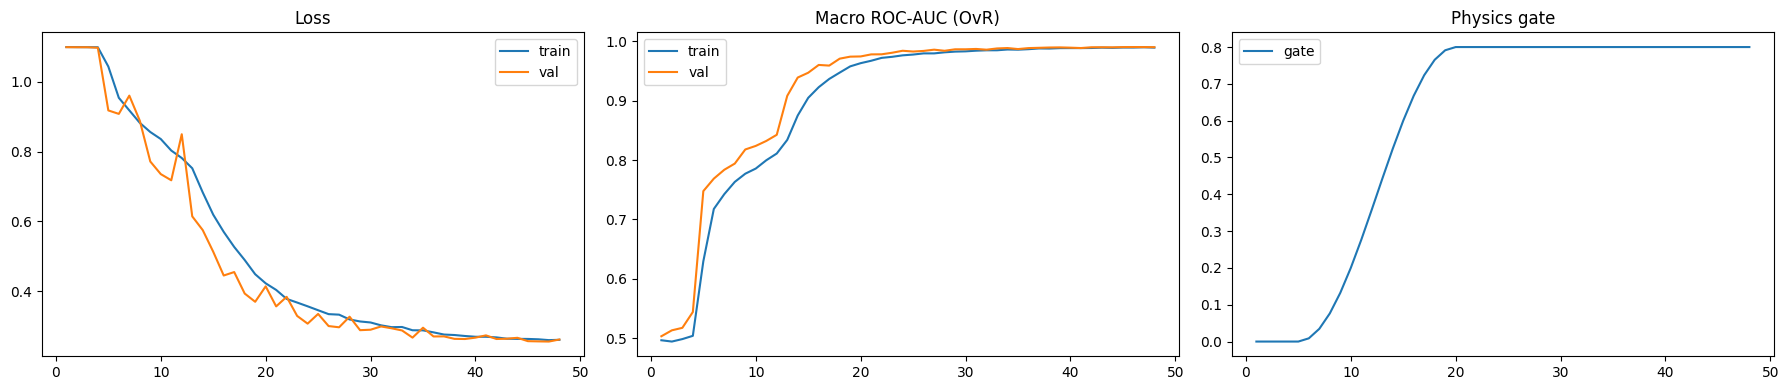

In [39]:

# =========================
# 13) Training curves
# =========================
hist_df = pd.read_csv(os.path.join(CFG.work_dir, "history.csv"))
display(hist_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_macro_auc_ovr"], label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_macro_auc_ovr"], label="val")
axes[1].set_title("Macro ROC-AUC (OvR)")
axes[1].legend()

axes[2].plot(hist_df["epoch"], hist_df["train_physics_gate"], label="gate")
axes[2].set_title("Physics gate")
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:

# =========================
# 14) TTA inference (single best checkpoint, no ensemble)
# =========================
def d4_transforms(x: torch.Tensor):
    outs = []
    for k in range(4):
        xr = torch.rot90(x, k, dims=(-2, -1))
        outs.append(xr)
        outs.append(torch.flip(xr, dims=(-1,)))
    return outs

@torch.no_grad()
def predict_probs(model, loader, checkpoint_path=None, use_tta=True, gate=None):
    if checkpoint_path is None:
        checkpoint_path = os.path.join(CFG.work_dir, "best.pth")

    state_dict, state_obj = load_checkpoint_state(checkpoint_path, DEVICE)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    this_gate = gate
    if this_gate is None:
        cfg_from_ckpt = state_obj.get("config", {}) if isinstance(state_obj, dict) else {}
        this_gate = float(cfg_from_ckpt.get("physics_gate_max", getattr(CFG, "physics_gate_max", 1.0)))
    model.set_physics_gate(this_gate)

    probs_list = []
    targets_list = []
    paths_list = []

    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label"].cpu().numpy().astype(np.int64)

        if use_tta:
            logits_tta = []
            for xt in d4_transforms(x):
                logits, _ = model(xt)
                logits_tta.append(logits.float())
            logits = torch.stack(logits_tta, dim=0).mean(dim=0)
        else:
            logits, _ = model(x)
            logits = logits.float()

        probs = torch.softmax(logits, dim=1)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-12)

        probs_list.append(probs.cpu().numpy().astype(np.float64))
        targets_list.append(y)
        paths_list.extend(batch["path"])

    probs_np = np.concatenate(probs_list, axis=0)
    targets_np = np.concatenate(targets_list, axis=0)

    pred_df = pd.DataFrame({
        "path": paths_list,
        "label": targets_np,
        "label_name": [IDX_TO_CLASS[i] for i in targets_np.tolist()],
        "pred": probs_np.argmax(axis=1),
        "pred_name": [IDX_TO_CLASS[i] for i in probs_np.argmax(axis=1).tolist()],
    })
    for i, c in enumerate(CFG.class_names):
        pred_df[f"p_{c}"] = probs_np[:, i]

    metrics = multiclass_metrics(targets_np, probs_np)
    return metrics, pred_df

best_ckpt_path = os.path.join(CFG.work_dir, "best.pth")
print("Using checkpoint:", os.path.basename(best_ckpt_path))

best_metrics, best_pred_df = predict_probs(
    model, val_loader, checkpoint_path=best_ckpt_path, use_tta=CFG.use_d4_tta
)

best_pred_df.to_csv(os.path.join(CFG.work_dir, "val_predictions_best_tta.csv"), index=False)

print("BEST:", {k: v for k, v in best_metrics.items() if k not in ["y_pred", "per_class_auc"]})
print("BEST per-class auc:", best_metrics["per_class_auc"])


Using checkpoint: best.pth
BEST: {'accuracy': 0.9448, 'macro_f1': 0.944612818091641, 'weighted_f1': 0.944612818091641, 'macro_auc_ovr': 0.99169392, 'weighted_auc_ovr': 0.9916939199999999}
BEST per-class auc: {'no': 0.9939076000000001, 'sphere': 0.9863765600000001, 'vort': 0.9947976}


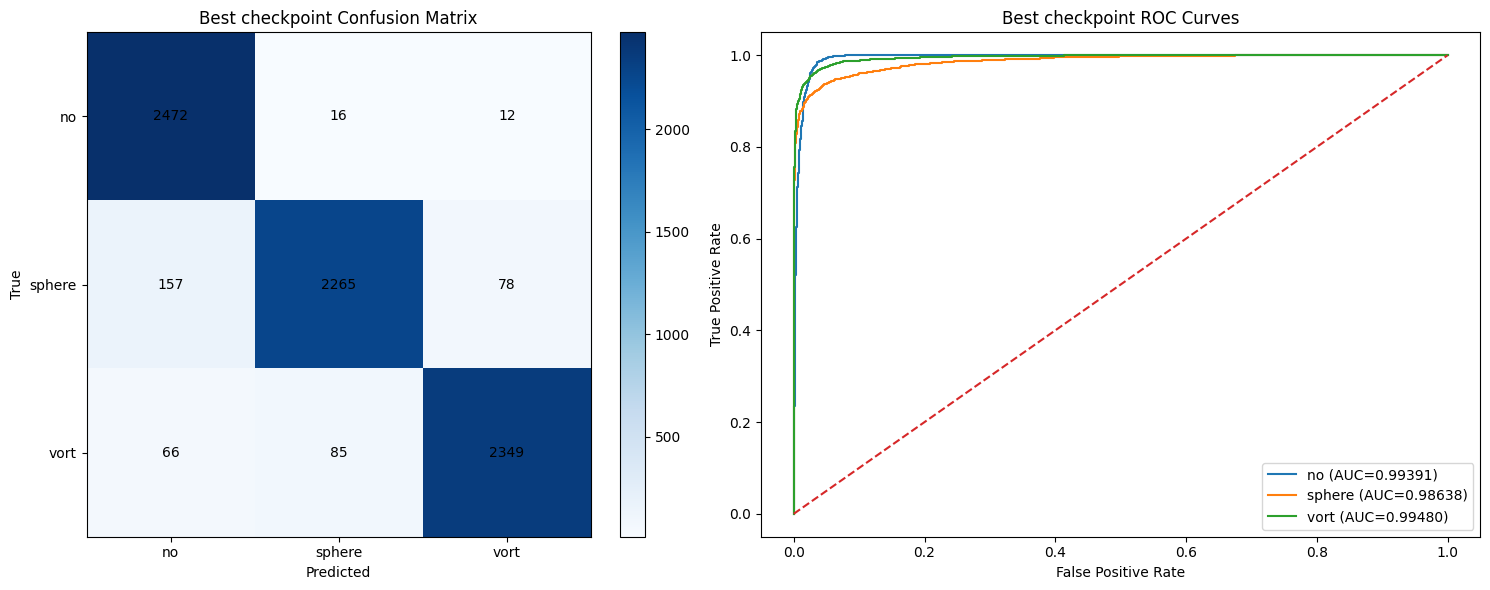

In [ ]:

# =========================
# 15) Confusion matrix + ROC curves
# =========================
def plot_confusion_and_roc(pred_df: pd.DataFrame, title_prefix: str):
    y_true = pred_df["label"].values
    probs = pred_df[[f"p_{c}" for c in CFG.class_names]].values
    y_pred = probs.argmax(axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CFG.class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title_prefix} Confusion Matrix")
    ax.set_xticks(range(len(CFG.class_names)))
    ax.set_yticks(range(len(CFG.class_names)))
    ax.set_xticklabels(CFG.class_names)
    ax.set_yticklabels(CFG.class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1]
    for i, c in enumerate(CFG.class_names):
        y_bin = (y_true == i).astype(np.int32)
        fpr, tpr, _ = roc_curve(y_bin, probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{c} (AUC={roc_auc:.5f})")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(f"{title_prefix} ROC Curves")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_confusion_and_roc(best_pred_df, "Best checkpoint")

In [ ]:

# =========================
# 16) Classification report
# =========================
print(classification_report(
    best_pred_df["label"].values,
    best_pred_df["pred"].values,
    target_names=list(CFG.class_names),
    digits=5,
))


              precision    recall  f1-score   support

          no    0.91725   0.98880   0.95168      2500
      sphere    0.95731   0.90600   0.93095      2500
        vort    0.96310   0.93960   0.95120      2500

    accuracy                        0.94480      7500
   macro avg    0.94589   0.94480   0.94461      7500
weighted avg    0.94589   0.94480   0.94461      7500



## What is genuinely new here?

This notebook is intentionally different from a DenseNet + pooled-physics-map design:

- **Main trunk is C8-equivariant**, not a generic CNN.
- The physics branch predicts **both** `psi` and `alpha_pred`.
- The lens equation is used explicitly to map from image plane to source plane.
- A source image is decoded and **re-lensed** to create an auxiliary consistency signal.
- Physics enters through **annealed fusion**, not full-strength from epoch 1.
- The final evaluation still supports:
  - best checkpoint
  - top-k checkpoint ensemble
  - D4 TTA
  - ROC curves
  - per-class AUC
  - confusion matrix
  - validation predictions CSV

## Practical notes

If training is unstable:

1. increase `warmup_epochs` to `6`,
2. reduce `w_recon` to `0.015`,
3. reduce `batch_size` to `12`,
4. set `img_size=150` instead of `160`.

If performance is stable but underwhelming:

1. increase `base_reps` from `12` to `14`,
2. increase `phys_hidden` from `192` to `256`,
3. extend to `40` epochs,
4. keep the staged gate exactly as-is.

## First experiment to run

Keep these defaults first:

- `img_size = 160`
- `physics_size = 80`
- `base_reps = 12`
- `phys_hidden = 192`
- `batch_size = 16`
- `epochs = 32`

That is the highest-value, P100-feasible first run for this architecture.